# Heisenberg‑Chain ESN Plotting Notebook

This Jupyter notebook reproduces every plot generated by the standalone
script you shared (defaulting to **`official_run`** mode).  Simply run the
cells top‑to‑bottom.  Edit the *Configuration* cell if you’d like to change
system size, time‑step, or switch to another mode.

> **Tip :** The notebook writes results to the same cache / output
directories used by the script (`./examples/Heisenberg_Chain/...`).

In [7]:
import sys
import os

# Go up two levels from current notebook directory
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("✓ Added to sys.path:", PROJECT_ROOT)

✓ Added to sys.path: c:\Users\Abeli\OneDrive\Documents\GitHub\echostate


In [8]:

# %pip install echostate qutip optuna --quiet   # ← uncomment if necessary
%matplotlib inline

import os, json, pickle, re
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

from echostate import ESN
from echostate.utils import mean_absolute_error
from Heisenberg_sim import HeisenbergChain
from qutip import Qobj, sigmaz, expect

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
print(f'Using device: {device}')


Using device: cpu


In [9]:
class ESNPredictor:
    """
    Train and evaluate an ESN on single‑qubit ⟨σ_z⟩ histories produced
    by a HeisenbergChain simulation.

    Two separate RNG seeds:
      • `history_seed`   – for generating / loading training histories
      • `reservoir_seed` – for initialising the ESN’s random weights
    """

    def __init__(self,
                 steps: int,
                 dt: float,
                 N: int,
                 qubit: int,
                 history_values: list = None,
                 reservoir_size: int = 100,
                 spectral_radius: float = 0.9,
                 input_scaling: float = 1.0,
                 ridge_param: float = 1e-3,
                 leak_rate: float = 0.9,
                 sparsity: float = 1.0,
                 feedback: int = 1,
                 bias_scaling: float = 0.2,
                 washout: int = 0,
                 batch_size: int = 1,
                 training_depth: int = 1,
                 history_seed: int = None,
                 reservoir_seed: int = None,
                 model_path=None,
                 cache_dir="./examples/Heisenberg_Chain/cache/",
                 device=torch.device('cpu')):
        # ---------------- core settings ----------------
        self.steps = steps
        self.dt = dt
        self.N = N
        self.qubit = qubit
        self.washout = washout
        self.batch_size = batch_size
        self.training_depth = training_depth

        # RNG seeds
        self.history_seed   = history_seed   if history_seed   is not None else reservoir_seed
        self.reservoir_seed = reservoir_seed if reservoir_seed is not None else history_seed

        # ---------------- ESN initialisation ----------
        if model_path is None or not os.path.exists(model_path):
            self.esn = ESN(
                device=device,
                base_input_dim=1,
                reservoir_size=reservoir_size,
                output_dim=1,
                feedback=feedback,
                spectral_radius=spectral_radius,
                sparsity=sparsity,
                input_scaling=input_scaling,
                ridge_param=ridge_param,
                leak_rate=leak_rate,
                bias_scaling=bias_scaling,
                washout=washout,
                batch_size=batch_size,
                seed=self.reservoir_seed,
            ).to(device)
        else:
            self.esn = torch.load(model_path, weights_only=False)
            self.esn.to(device).eval()

        # ---------------- data preparation -------------
        self.test_history = history_values
        self.histories = []

        fmt_dt_val = str(round(self.dt, 5)).replace(".", "_", 1)
        qubit_tag   = f"Qbts(dpth{training_depth}){self.N}"
        cache_name  = f"Historydata_Seed{self.history_seed}_T{steps*dt}_{qubit_tag}_dt{fmt_dt_val}.pkl"
        cache_path  = os.path.join(cache_dir, cache_name)

        np.random.seed(self.history_seed)
        if history_values is None or training_depth > 0:
            if os.path.exists(cache_path):
                with open(cache_path, 'rb') as f:
                    self.histories = pickle.load(f)
                print(f"Loaded {len(self.histories)} training histories from cache.")
            else:
                for _ in range(training_depth):
                    chain = HeisenbergChain(num_qubits=N, target_qubit=qubit, dt=dt)
                    chain.evolve(steps)
                    self.histories.append(chain.get_sz())
                print(f"Collected {len(self.histories)} simulation histories.")
                os.makedirs(cache_dir, exist_ok=True)
                with open(cache_path, 'wb') as f:
                    pickle.dump(self.histories, f)
                print(f"Saved to {cache_path}.")

    # --------------------------------------------------
    def _build_dataset(self):
        inputs, targets = [], []
        for z_seq in self.histories:
            arr = np.asarray(z_seq)
            X = torch.tensor(arr[:-1], dtype=torch.float32, device=device).unsqueeze(-1)
            Y = torch.tensor(arr[1:],  dtype=torch.float32, device=device).unsqueeze(-1)
            inputs.append(X)
            targets.append(Y)
        assert len(inputs) == self.batch_size, (
            f"Expected batch_size={self.batch_size}, got {len(inputs)}"
        )
        return inputs, targets

    def train(self):
        inputs, targets = self._build_dataset()
        print(f"Training ESN on {len(inputs)} sequences (washout={self.washout})")
        self.esn.fit(inputs, targets)

    # --------------------------------------------------
    def predict_and_plot(self, acc_history=None, acc_chain=None, name="test"):
        """Quick convenience plot (single sequence)"""
        if self.test_history is None:
            raise ValueError("No test history provided.")

        # reduced density matrices → σ_z expectation
        if isinstance(self.test_history[0], (float, np.floating, np.complexfloating)):
            z_test = np.asarray(self.test_history)
        else:
            z_test = np.asarray([
                float(expect(sigmaz(), Qobj(rho, dims=[[2],[2]])))
                for rho in self.test_history
            ])

        if acc_history is not None and acc_chain is not None:
            acc_z  = [float(expect(sigmaz(), Qobj(rho, dims=[[2],[2]])))
                      for rho in acc_history]
            acc_dt = acc_chain.dt

        X_test = torch.tensor(z_test[:-1], dtype=torch.float32, device=device)                     .unsqueeze(-1).unsqueeze(0)
        preds  = self.esn.predict(X_test)[0].cpu().numpy().flatten()
        true   = z_test[self.washout+1 : self.washout+1+len(preds)]

        coarse_t = np.arange(len(preds))*self.dt
        plt.figure(figsize=(8,4))
        plt.plot(coarse_t, preds, 'o', label='Prediction', ms=4)
        plt.plot(coarse_t, true,  '-o', label='True', ms=1)
        plt.legend(); plt.xlabel("Time"); plt.ylabel("⟨σ_z⟩"); plt.show()

    def debug(self):
        self.esn.trainer.debug_covariance()


In [10]:

def plot_hyperparams_vs_N(perm_dir='./examples/Heisenberg_Chain/trained_esns/'):
    """Plot tuned hyper‑parameters versus system size N."""
    param_files = [f for f in os.listdir(perm_dir)
                   if f.startswith('bestparams_') and f.endswith('.json')]
    if not param_files:
        print('No bestparams_ files found.'); return
    import re
    data = {}
    for fname in param_files:
        m = re.search(r'Qbts\(\d+\)(\d+)', fname)
        if not m: continue
        N = int(m.group(1))
        try:
            with open(os.path.join(perm_dir,fname),'r') as f:
                js = json.load(f)
            data[N] = next(iter(js.values()))
        except Exception as e:
            print('Skipping', fname, e)

    if not data:
        print('Could not parse any files.'); return
    Ns = sorted(data)
    params = list(data[Ns[0]])
    fig, axes = plt.subplots(len(params),1, figsize=(8,2.5*len(params)), sharex=True)
    if len(params)==1: axes=[axes]
    for ax,p in zip(axes,params):
        ax.plot(Ns,[data[N][p] for N in Ns],'o-'); ax.set_ylabel(p); ax.grid(ls=':')
    axes[-1].set_xlabel('System size N')
    plt.show()


In [11]:

# ------------------------- CONFIGURATION -------------------------
T              = 100
N_list         = [2]
train_seed     = 31415
test_seed      = 31
qubit_list     = [0,1]
washout        = 75

dt             = 0.2   # ESN step
acc_dt         = 0.05  # accurate reference step
training_depth = 1000
testing_depth  = 6     # ensemble size

# Modes (choose ONE True)
do_tune        = False
do_plot_hyper  = False
official_run   = True
single_run     = not (do_tune or do_plot_hyper or official_run)

ignore_qubit   = True

n_trials       = 50
study_name     = f'esn_tune_T{T}_dt{dt}'
study_dir      = './examples/Heisenberg_Chain/studies/'
os.makedirs(study_dir, exist_ok=True)



Running N=2, qubit=0
Collected 1000 simulation histories.
Saved to ./examples/Heisenberg_Chain/cache/Historydata_Seed31415_T100.0_Qbts(dpth1000)2_dt0_2.pkl.
Training ESN on 1000 sequences (washout=75)
Loaded 1000 training histories from cache.
Training ESN on 1000 sequences (washout=75)
Loaded 1000 training histories from cache.
Training ESN on 1000 sequences (washout=75)
Loaded 1000 training histories from cache.
Training ESN on 1000 sequences (washout=75)
Loaded 1000 training histories from cache.
Training ESN on 1000 sequences (washout=75)
Loaded 1000 training histories from cache.
Training ESN on 1000 sequences (washout=75)

Running N=2, qubit=1
Loaded 1000 training histories from cache.


C:\Users\Abeli\AppData\Local\Temp\ipykernel_13440\3678045534.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  predictor.esn = torch.load(model_path)


Loaded 1000 training histories from cache.
Loaded 1000 training histories from cache.
Loaded 1000 training histories from cache.
Loaded 1000 training histories from cache.
Loaded 1000 training histories from cache.


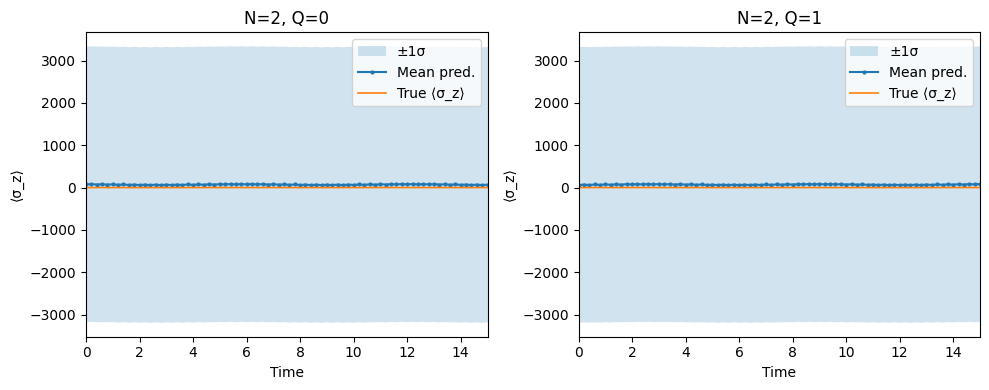

In [12]:

# --------------------------- EXECUTION ---------------------------
# High‑resolution reference (for ensemble / single modes)
np.random.seed(test_seed)
acc_chain = HeisenbergChain(num_qubits=N_list[0],
                            target_qubit=qubit_list[0],
                            dt=acc_dt)
acc_chain.evolve(int(T/acc_dt), store_reduced=True)

raw = acc_chain.get_sz()
z_test_global = np.asarray([float(expect(sigmaz(), Qobj(rho, dims=[[2],[2]])))
                            for rho in raw])

if do_plot_hyper:
    plot_hyperparams_vs_N()
# -----------------------------------------------------------------
elif official_run:
    model_dir = './examples/Heisenberg_Chain/cache/'
    param_dir = './examples/Heisenberg_Chain/trained_esns/'
    os.makedirs(model_dir, exist_ok=True)

    mae_records = []
    fig, axs = plt.subplots(len(N_list), len(qubit_list),
                            figsize=(5*len(qubit_list), 4*len(N_list)),
                            squeeze=False)

    for r,N in enumerate(N_list):
        for c,Q in enumerate(qubit_list):
            print(f'\nRunning N={N}, qubit={Q}')
            steps = int(T/dt)
            fmt_dt = str(round(dt,5)).replace('.','_',1)
            qtag   = f"Qbts({(0 if ignore_qubit else Q)+1}){N}"
            param_name = f"Seed{train_seed}_{qtag}_dt{fmt_dt}_dpth50_wsht{washout}"
            best_file  = os.path.join(param_dir, f'bestparams_{param_name}.json')
            try:
                with open(best_file,'r') as f: best = json.load(f)
                best = best.get(str(round(dt,5)), {})
            except: best = {}

            # build accurate new chain for this N,Q
            np.random.seed(train_seed)
            acc_chain = HeisenbergChain(num_qubits=N, target_qubit=Q, dt=acc_dt)
            acc_chain.evolve(int(T/acc_dt), store_reduced=True)
            raw = acc_chain.get_sz()
            z_test = np.asarray([float(expect(sigmaz(), Qobj(rho, dims=[[2],[2]])))
                                 for rho in raw])

            seeds = list(range(train_seed, train_seed+testing_depth))
            all_preds=[]
            for ex,seed in enumerate(seeds):
                model_path = os.path.join(model_dir,
                        f"trainedmodel_N{N}_{qtag}_dt{fmt_dt}_Ex{ex}.pt")
                predictor = ESNPredictor(
                    steps=steps, dt=dt, N=N,
                    qubit=(0 if ignore_qubit else Q),
                    reservoir_size=best.get('reservoir_size', 900),
                    spectral_radius=best.get('spectral_radius', 1.25),
                    input_scaling=best.get('input_scaling', 0.55),
                    ridge_param=best.get('ridge_param', 1e-1),
                    leak_rate=best.get('leak_rate', 0.9),
                    sparsity=best.get('sparsity', 0.2),
                    feedback=best.get('feedback', 1),
                    bias_scaling=best.get('bias_scaling', 0.4),
                    washout=washout,
                    batch_size=training_depth,
                    training_depth=training_depth,
                    history_seed=train_seed,
                    reservoir_seed=seed,
                    model_path=model_path if os.path.exists(model_path) else None,
                    device=device
                )
                if os.path.exists(model_path):
                    predictor.esn = torch.load(model_path)
                else:
                    predictor.train()
                    torch.save(predictor.esn, model_path)

                X_test = torch.tensor(z_test[:-1], dtype=torch.float32, device=device)                               .unsqueeze(-1).unsqueeze(0)
                pred = predictor.esn.predict(X_test)[0].cpu().numpy().flatten()
                all_preds.append(pred)
                true = z_test[washout+1 : washout+1+len(pred)]
                mae  = mean_absolute_error(torch.tensor(pred), torch.tensor(true)).item()
                mae_records.append(dict(N=N,qubit=Q,ex=ex,MAE=mae))

            # plot panel
            ax = axs[r][c]
            all_preds=np.stack(all_preds)
            t = np.arange(all_preds.shape[1])*dt
            ax.fill_between(t, all_preds.mean(0)-all_preds.std(0),
                               all_preds.mean(0)+all_preds.std(0),
                               alpha=0.2,label='±1σ')
            ax.plot(t, all_preds.mean(0), 'o-', ms=2,label='Mean pred.')
            true = z_test[washout+1 : washout+1+len(all_preds.mean(0))]
            ax.plot(t,true,'-',lw=1.2,label='True ⟨σ_z⟩')
            ax.set_xlim(0,15)
            ax.set_title(f'N={N}, Q={Q}')
            ax.set_xlabel('Time'); ax.set_ylabel('⟨σ_z⟩'); ax.legend()
    plt.tight_layout(); plt.show()
# -----------------------------------------------------------------
else:
    print('single_run / tune modes not ported – tweak the notebook if needed.')
